In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm -q


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

import xgboost as xgb
import lightgbm as lgb

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)


In [4]:
class UrbanSimulator:
    def __init__(self):
        self.param_bounds = {
            "population_growth_rate": (0.005, 0.05),
            "housing_price_base": (100000, 500000),
            "employment_rate": (0.5, 0.95),
            "land_development_capacity": (50, 500),
            "transportation_cost": (0.01, 0.5),
            "income_median": (30000, 120000),
            "zoning_density": (0.1, 1.0),
            "amenity_score": (0.0, 10.0)
        }

    def generate_random_params(self):
        return {
            k: np.random.uniform(v[0], v[1])
            for k, v in self.param_bounds.items()
        }

    def simulate(self, params):
        affordability = np.tanh(params["income_median"] / params["housing_price_base"])
        dev_pressure = np.log1p(
            params["population_growth_rate"]
            * params["land_development_capacity"]
            * params["zoning_density"]
        )
        economic_vitality = params["employment_rate"] * np.sqrt(params["income_median"] / 120000)
        accessibility = np.exp(-params["transportation_cost"])
        quality_of_life = np.tanh(params["amenity_score"] / 10)

        udi = (
            25 * affordability +
            20 * dev_pressure +
            20 * economic_vitality +
            15 * accessibility +
            20 * quality_of_life
        )

        udi += 10 * affordability * params["employment_rate"] * params["zoning_density"]
        udi += np.random.normal(0, 3)

        return np.clip(udi, 0, 100)


In [5]:
simulator = UrbanSimulator()
data = []

for _ in range(1000):
    params = simulator.generate_random_params()
    params["urban_development_index"] = simulator.simulate(params)
    data.append(params)

df = pd.DataFrame(data)
df.head()


,population_growth_rate,housing_price_base,employment_rate,land_development_capacity,transportation_cost,income_median,zoning_density,amenity_score,urban_development_index
0,0.021854,480285.722564,0.829397,319.396318,0.086449,44039.506830,0.152275,8.661761,59.416688
1,0.005926,487963.940865,0.874599,145.552600,0.099094,46506.405887,0.373818,5.247564,44.679726
2,0.024438,216491.656079,0.775334,112.772237,0.153151,62972.565896,0.510463,7.851760,63.178260
3,0.031659,118580.165088,0.773395,126.735856,0.041875,115399.698353,0.969069,8.083973,94.763857
4,0.018708,139068.845603,0.807905,248.068622,0.069799,74565.921910,0.130950,9.093204,65.876503


In [6]:
print("Shape:", df.shape)
df.describe()

Shape: (1000, 9)


,population_growth_rate,housing_price_base,employment_rate,land_development_capacity,transportation_cost,income_median,zoning_density,amenity_score,urban_development_index
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.026866,300649.637074,0.721616,271.753652,0.254142,73044.827324,0.543009,5.027184,66.762948
std,0.012759,115316.367827,0.129664,130.012939,0.142560,26141.926157,0.262309,2.861705,15.682429
min,0.005061,100021.130773,0.500061,51.961811,0.010201,30002.764696,0.100010,0.002270,21.716405
25%,0.016176,201262.306196,0.605522,161.091408,0.124322,50887.779917,0.319909,2.508524,55.415289
50%,0.026340,303207.684985,0.724831,273.851781,0.253899,71790.689760,0.534318,5.007280,66.274373
75%,0.036978,399726.924207,0.831283,385.033689,0.382583,94232.431454,0.773232,7.505640,77.864454
max,0.049971,499887.069314,0.949256,499.757306,0.498525,119725.447567,0.999287,9.978209,100.000000


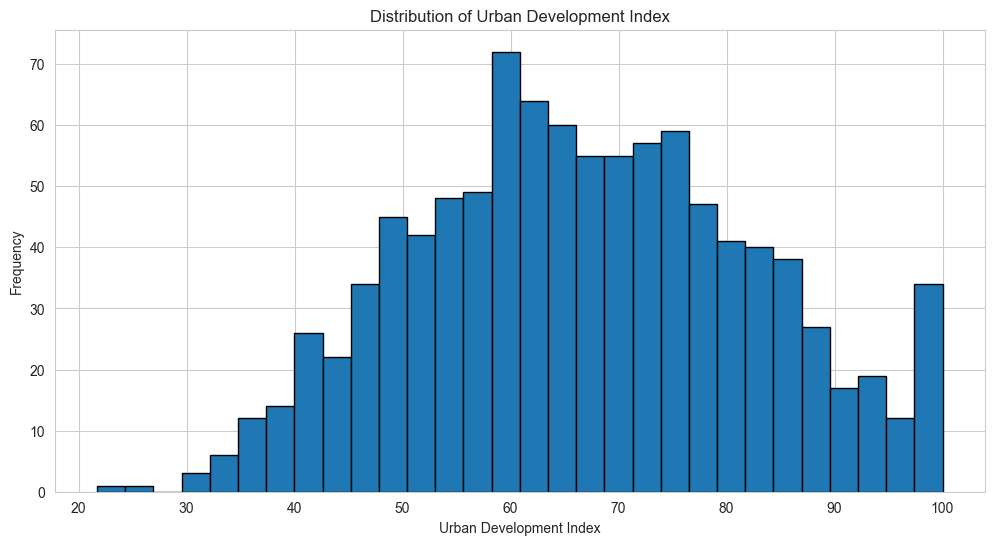

In [14]:
plt.hist(df["urban_development_index"], bins=30, edgecolor="black")
plt.xlabel("Urban Development Index")
plt.ylabel("Frequency")
plt.title("Distribution of Urban Development Index")
plt.savefig("urban_development_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

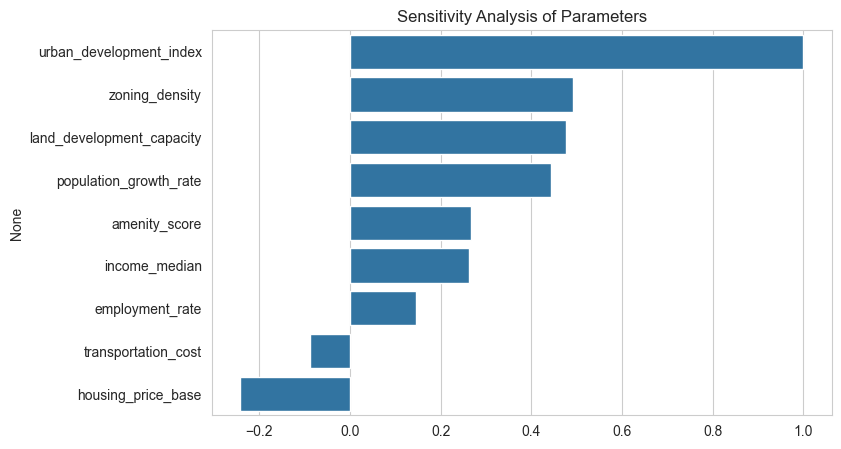

urban_development_index      1.000000
zoning_density               0.491197
land_development_capacity    0.477165
population_growth_rate       0.442642
amenity_score                0.267509
income_median                0.262679
employment_rate              0.145008
transportation_cost         -0.087413
housing_price_base          -0.243222
Name: urban_development_index, dtype: float64

In [15]:
correlation = df.corr()["urban_development_index"].sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=correlation.values, y=correlation.index)
plt.title("Sensitivity Analysis of Parameters")
plt.savefig("sensitivity_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

correlation

In [16]:
X = df.drop("urban_development_index", axis=1)
y = df["urban_development_index"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Decision Tree": DecisionTreeRegressor(max_depth=10),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": xgb.XGBRegressor(verbosity=0),
    "LightGBM": lgb.LGBMRegressor(verbose=-1),
    "SVR": SVR()
}

In [18]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results.append({
        "Model": name,
        "Test R2": r2_score(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "MAE": mean_absolute_error(y_test, preds),
        "CV R2": cross_val_score(model, X_train, y_train, cv=5, scoring="r2").mean()
    })

results_df = pd.DataFrame(results).sort_values("Test R2", ascending=False)
results_df


,Model,Test R2,RMSE,MAE,CV R2
5,Gradient Boosting,0.923793,4.529742,3.669053,0.904892
0,Linear Regression,0.919874,4.644733,3.593015,0.894531
1,Ridge Regression,0.919867,4.644956,3.594343,0.894535
7,LightGBM,0.916496,4.741646,3.704569,0.906320
8,SVR,0.890941,5.418826,4.241624,0.842881
2,Lasso Regression,0.880908,5.662605,4.625675,0.859092
6,XGBoost,0.874866,5.804463,4.566469,0.860168
4,Random Forest,0.863162,6.069853,4.890342,0.848278
3,Decision Tree,0.698503,9.009833,7.225306,0.605069


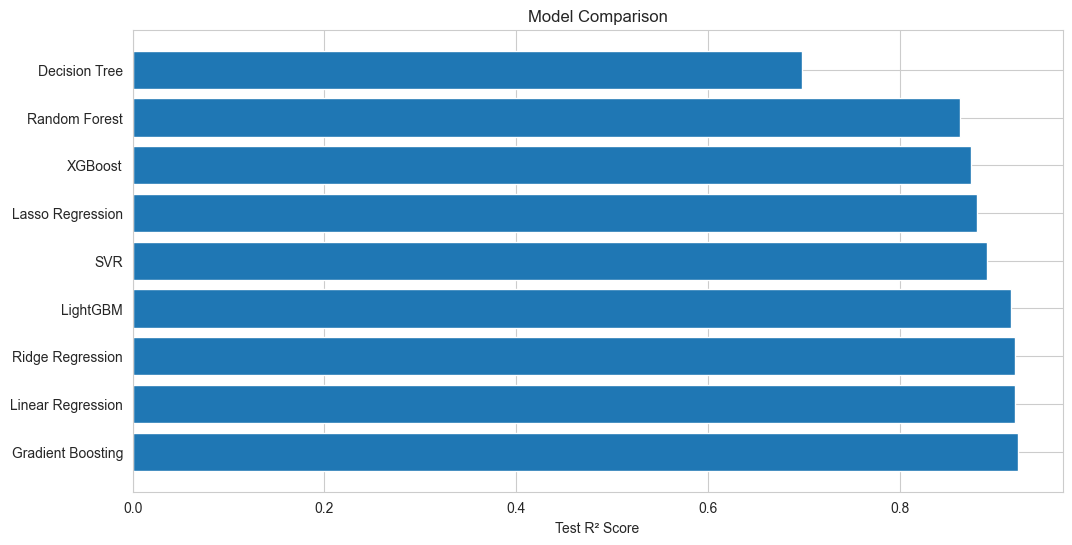

Model      Gradient Boosting
Test R2             0.923793
RMSE                4.529742
MAE                 3.669053
CV R2               0.904892
Name: 5, dtype: object

In [19]:
plt.barh(results_df["Model"], results_df["Test R2"])
plt.xlabel("Test R² Score")
plt.title("Model Comparison")
plt.savefig("model_comparison_plot.png", dpi=300, bbox_inches="tight")
plt.show()

best_model = results_df.iloc[0]
best_model

In [20]:
df.to_csv("simulation_data.csv", index=False)
results_df.to_csv("model_comparison.csv", index=False)

print("Files saved successfully.")

Files saved successfully.
